# FedProx label-flipping robustness (ToN-IoT)

## 1. Imports

In [1]:
import os
import json
import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Subset

import flwr as fl
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix,
)

warnings.filterwarnings("ignore")

## 2. Configuration

In [2]:
CSV_PATH = r"../../../data/ToN-IoT_extracted.csv"
TARGET_MULTICLASS = "type"
NORMAL_CLASS = "normal"
DROP_COLS = ['label', 'type', 'subcategory', 'attack']

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

NUM_CLIENTS = 10
NUM_PARTITIONS = 10
BATCH_SIZE = 32
EPOCHS = 5
EPSILON = 1e-8
LEARNING_RATE = 0.001
MAX_ALPHA = 10.0
MIN_ALPHA = 0.1
learning_rate_server = 1.0

BINARY = False
IID = True
DIRICHLET_ALPHA = 1.0

BASE_SEED = 123
NUM_ROUNDS = 15

GPU_PER_CLIENT = 0.5 if torch.cuda.is_available() else 0.0
CPUS_PER_CLIENT = max(1, (os.cpu_count() or 2) // 2)

ENABLE_LABEL_FLIP = False
MALICIOUS_FRAC = 0.0
FLIP_PROB = 0.0
FLIP_MODE = "random"
SOURCE_CLASS = 0
TARGET_CLASS = 1
POISON_SEED = 123
MALICIOUS_CLIENTS = set()

MU = 0.01

Using device: cuda


## 3. Data loading

In [3]:
def load_dataset(file_path, target_multiclass, normal_class, binary,
                 drop_cols, test_size=0.3, random_state=42):
    df = pd.read_csv(file_path)
    df = df.drop_duplicates()

    df = df.dropna(subset=[target_multiclass])
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    categorical_cols = df.select_dtypes(exclude=[np.number]).columns
    for col in numeric_cols:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
    for col in categorical_cols:
        if df[col].isnull().any():
            mode_val = df[col].mode()
            df[col] = df[col].fillna(mode_val[0] if not mode_val.empty else "Unknown")

    y_multi = df[target_multiclass].astype(str).str.strip()
    if binary:
        y = np.where(y_multi.str.lower() == normal_class.lower(), "Benign", "Attack")
        y = pd.Series(y, index=df.index)
    else:
        y = y_multi

    X = df.drop(columns=drop_cols, errors="ignore").copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y)

    non_numeric_cols = list(
        set(X_train.select_dtypes(exclude=[np.number]).columns.tolist())
        | set(X_test.select_dtypes(exclude=[np.number]).columns.tolist()))
    feature_encoders = {}
    for col in non_numeric_cols:
        le_col = LabelEncoder()
        le_col.fit(X_train[col].astype(str))
        feature_encoders[col] = le_col
        mapping = {cls: idx for idx, cls in enumerate(le_col.classes_)}
        X_train[col] = le_col.transform(X_train[col].astype(str))
        X_test[col] = X_test[col].astype(str).map(mapping).fillna(-1).astype(int)

    def safe_numeric(df_):
        df_ = df_.apply(lambda c: c.map(lambda v: str(v).strip() if isinstance(v, str) else v))
        df_ = df_.apply(pd.to_numeric, errors="coerce")
        return df_.replace([np.inf, -np.inf], np.nan).fillna(0)

    X_train = safe_numeric(X_train)
    X_test = safe_numeric(X_test)

    global INPUT_DIM
    INPUT_DIM = X_train.shape[1]

    y_train = pd.Series(np.asarray(y_train)).astype(str).str.strip()
    y_test = pd.Series(np.asarray(y_test)).astype(str).str.strip()
    label_encoder = LabelEncoder()
    y_train_enc = label_encoder.fit_transform(y_train.values)
    y_test_enc = label_encoder.transform(y_test.values)
    class_names = label_encoder.classes_
    num_classes = len(class_names)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train.values.astype(np.float64))
    X_test_scaled = scaler.transform(X_test.values.astype(np.float64))

    train_dataset = TensorDataset(torch.from_numpy(X_train_scaled).float(),
                                  torch.from_numpy(y_train_enc).long())
    test_dataset = TensorDataset(torch.from_numpy(X_test_scaled).float(),
                                 torch.from_numpy(y_test_enc).long())
    print(f"Classes ({num_classes}): {list(class_names)}")
    print(f"Features: {INPUT_DIM} | Train: {len(train_dataset)} | Test: {len(test_dataset)}")
    return (train_dataset, test_dataset, class_names, num_classes,
            scaler, label_encoder, feature_encoders)


(
    train_dataset, test_dataset, class_names, NUM_CLASSES,
    scaler, label_encoder, feature_encoders,
) = load_dataset(CSV_PATH, TARGET_MULTICLASS, NORMAL_CLASS, BINARY, DROP_COLS)

Classes (10): ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']
Features: 42 | Train: 37899 | Test: 16243


## 4. Partitioning (IID and Non-IID)

In [4]:
def partition_dataset_iid(dataset, num_partitions):
    labels = np.array([dataset[i][1] for i in range(len(dataset))])
    indices_by_class = [[] for _ in range(NUM_CLASSES)]
    for idx, label in enumerate(labels):
        indices_by_class[label].append(idx)
    partitions = [[] for _ in range(num_partitions)]
    for c in range(NUM_CLASSES):
        indices = indices_by_class[c]
        np.random.shuffle(indices)
        per = len(indices) // num_partitions
        rem = len(indices) % num_partitions
        start = 0
        for p in range(num_partitions):
            extra = 1 if p < rem else 0
            end = start + per + extra
            partitions[p].extend(indices[start:end])
            start = end
    for p in range(num_partitions):
        np.random.shuffle(partitions[p])
    return partitions


def partition_dataset_dirichlet(dataset, num_partitions, dirichlet_alpha):
    labels = np.array([dataset[i][1] for i in range(len(dataset))])
    indices_by_class = [[] for _ in range(NUM_CLASSES)]
    for idx, label in enumerate(labels):
        indices_by_class[label].append(idx)
    partitions = [[] for _ in range(num_partitions)]
    for c in range(NUM_CLASSES):
        indices = indices_by_class[c]
        np.random.shuffle(indices)
        proportions = np.random.dirichlet([dirichlet_alpha] * num_partitions)
        counts = (proportions * len(indices)).astype(int)
        diff = len(indices) - counts.sum()
        if diff > 0:
            for k in np.argsort(proportions)[-diff:]:
                counts[k] += 1
        elif diff < 0:
            for k in np.argsort(proportions)[:abs(diff)]:
                if counts[k] > 0:
                    counts[k] -= 1
        start = 0
        for p in range(num_partitions):
            end = start + counts[p]
            partitions[p].extend(indices[start:end])
            start = end
    for p in range(num_partitions):
        np.random.shuffle(partitions[p])
    return partitions


def partition_dataset(dataset, num_partitions):
    if IID:
        return partition_dataset_iid(dataset, num_partitions)
    return partition_dataset_dirichlet(dataset, num_partitions, DIRICHLET_ALPHA)


train_partitions = partition_dataset(train_dataset, NUM_PARTITIONS)
print(f"Created {len(train_partitions)} partitions ({'IID' if IID else 'Non-IID'})")

Created 10 partitions (IID)


## 5. Model, parameters, and evaluation

In [5]:
class model(nn.Module):
    def __init__(self, INPUT_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        self.fc1 = nn.Linear(INPUT_DIM, 50)
        self.fc2 = nn.Linear(50, 25)
        self.fc3 = nn.Linear(25, num_classes)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


def get_ndarrays(net):
    return [val.detach().cpu().numpy() for _, val in net.state_dict().items()]


def set_ndarrays(net, params):
    state_dict = net.state_dict()
    new_state_dict = {k: torch.tensor(v, device=device)
                      for k, v in zip(state_dict.keys(), params)}
    net.load_state_dict(new_state_dict, strict=True)


@torch.no_grad()
def evaluate_global_model(params, test_loader):
    net = model(INPUT_DIM, NUM_CLASSES).to(device)
    set_ndarrays(net, fl.common.parameters_to_ndarrays(params)
                 if not isinstance(params, list) else params)
    net.eval()
    loss_fn = nn.CrossEntropyLoss()
    total_loss, total = 0.0, 0
    y_true, y_pred = [], []
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = net(xb)
        total_loss += loss_fn(logits, yb).item() * yb.size(0)
        total += yb.size(0)
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(logits.argmax(dim=1).cpu().numpy())
    return total_loss / max(1, total), {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    }

## 6. Label-flipping wrapper

In [6]:
class LabelFlippedDataset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, num_classes, flip_prob=1.0, mode="random",
                 source_class=0, target_class=1, seed=0):
        self.base = base_dataset
        self.num_classes = int(num_classes)
        self.flip_prob = float(flip_prob)
        self.mode = str(mode)
        self.source_class = int(source_class)
        self.target_class = int(target_class)
        self.rng = np.random.RandomState(seed)

    def __len__(self):
        return len(self.base)

    def _flip_label(self, y):
        if self.mode == "targeted":
            return self.target_class if y == self.source_class else y
        new_y = y
        while new_y == y:
            new_y = int(self.rng.randint(0, self.num_classes))
        return new_y

    def __getitem__(self, idx):
        x, y = self.base[idx]
        y_int = int(y.item()) if torch.is_tensor(y) else int(y)
        if self.rng.rand() < self.flip_prob:
            y_int = self._flip_label(y_int)
        return x, torch.tensor(y_int, dtype=torch.long)

## 7. Flower client

In [7]:
def client_fn(cid):
    cid_int = int(cid)
    partition_indices = train_partitions[cid_int]
    base_subset = Subset(train_dataset, partition_indices)

    is_malicious = (ENABLE_LABEL_FLIP and (cid_int in MALICIOUS_CLIENTS))
    if is_malicious:
        client_dataset = LabelFlippedDataset(
            base_dataset=base_subset, num_classes=NUM_CLASSES,
            flip_prob=FLIP_PROB, mode=FLIP_MODE,
            source_class=SOURCE_CLASS, target_class=TARGET_CLASS,
            seed=POISON_SEED + cid_int)
    else:
        client_dataset = base_subset

    train_loader = DataLoader(client_dataset, batch_size=BATCH_SIZE, shuffle=True)

    class BaselineClient(fl.client.NumPyClient):
        def __init__(self):
            self.net = model(INPUT_DIM, NUM_CLASSES).to(device)
            self.train_loader = train_loader
            self.is_malicious = is_malicious

        def get_parameters(self, config=None):
            return get_ndarrays(self.net)

        def fit(self, parameters, config):
            set_ndarrays(self.net, parameters)
            self.net.train()
            global_params = [p.detach().clone() for p in self.net.parameters()]
            opt = optim.SGD(self.net.parameters(), lr=LEARNING_RATE, momentum=0.9)
            loss_fn = nn.CrossEntropyLoss()
            total_loss, total_seen = 0.0, 0
            for _ in range(EPOCHS):
                for xb, yb in self.train_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    opt.zero_grad()
                    ce_loss = loss_fn(self.net(xb), yb)
                    prox_term = 0.0
                    for w, w0 in zip(self.net.parameters(), global_params):
                        prox_term += torch.sum((w - w0) ** 2)
                    loss = ce_loss + (MU / 2.0) * prox_term
                    loss.backward()
                    opt.step()
                    total_loss += loss.item() * yb.size(0)
                    total_seen += yb.size(0)
            avg_train_loss = total_loss / max(1, total_seen)
            return (get_ndarrays(self.net), len(client_dataset),
                    {"train_loss": float(avg_train_loss),
                      "is_malicious": int(self.is_malicious)})

        def evaluate(self, parameters, config):
            return 0.0, len(client_dataset), {}

    return BaselineClient().to_client()

## 8. Evaluation history

In [8]:
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

eval_rounds, eval_loss, eval_acc, eval_prec, eval_rec, eval_f1 = [], [], [], [], [], []


def reset_histories():
    global eval_rounds, eval_loss, eval_acc, eval_prec, eval_rec, eval_f1
    eval_rounds, eval_loss, eval_acc, eval_prec, eval_rec, eval_f1 = [], [], [], [], [], []

## 9. Strategy

In [9]:
def make_strategy():
    def evaluate_fn(server_round, parameters, config):
        loss, metrics = evaluate_global_model(parameters, test_loader)
        eval_rounds.append(server_round)
        eval_loss.append(loss)
        eval_acc.append(metrics["accuracy"])
        eval_prec.append(metrics["precision"])
        eval_rec.append(metrics["recall"])
        eval_f1.append(metrics["f1"])
        print(f"[FedProx][Round {server_round}] loss={loss:.4f} "
              f"acc={metrics['accuracy']:.4f} f1={metrics['f1']:.4f}")
        return loss, metrics

    return fl.server.strategy.FedAvg(
        fraction_fit=1.0,
        min_fit_clients=NUM_CLIENTS,
        min_available_clients=NUM_CLIENTS,
        evaluate_fn=evaluate_fn,
    )

## 10. Poisoning helper

In [10]:
def set_poisoning(mal_frac, flip_prob, mode="random", seed=123,
                  source_class=0, target_class=1):
    global ENABLE_LABEL_FLIP, MALICIOUS_FRAC, FLIP_PROB, FLIP_MODE
    global SOURCE_CLASS, TARGET_CLASS, POISON_SEED, MALICIOUS_CLIENTS
    POISON_SEED = int(seed)
    ENABLE_LABEL_FLIP = (mal_frac > 0) and (flip_prob > 0)
    MALICIOUS_FRAC = float(mal_frac)
    FLIP_PROB = float(flip_prob)
    FLIP_MODE = str(mode)
    SOURCE_CLASS = int(source_class)
    TARGET_CLASS = int(target_class)
    rng = np.random.RandomState(POISON_SEED)
    num_mal = int(NUM_CLIENTS * MALICIOUS_FRAC)
    if num_mal <= 0:
        MALICIOUS_CLIENTS = set()
    else:
        MALICIOUS_CLIENTS = set(rng.choice(np.arange(NUM_CLIENTS),
                                           size=num_mal, replace=False).tolist())
    print(f"[Poison] mal_frac={MALICIOUS_FRAC}, flip_prob={FLIP_PROB}, "
          f"malicious_clients={sorted(MALICIOUS_CLIENTS)}")

## 11. Experiment runner

In [11]:
def run_one_experiment(num_rounds=15, seed=123):
    np.random.seed(seed)
    random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    reset_histories()
    strategy = make_strategy()
    fl.simulation.start_simulation(
        client_fn=client_fn,
        num_clients=NUM_CLIENTS,
        config=fl.server.ServerConfig(num_rounds=num_rounds),
        strategy=strategy,
        client_resources={"num_cpus": CPUS_PER_CLIENT, "num_gpus": GPU_PER_CLIENT},
    )
    if len(eval_rounds) == 0:
        return None
    return {
        "final_round": int(eval_rounds[-1]),
        "final_loss": float(eval_loss[-1]),
        "final_accuracy": float(eval_acc[-1]),
        "final_precision": float(eval_prec[-1]),
        "final_recall": float(eval_rec[-1]),
        "final_f1": float(eval_f1[-1]),
        "rounds": list(eval_rounds),
        "acc_curve": list(eval_acc),
        "loss_curve": list(eval_loss),
    }

## 12. Rounds and seed

In [12]:
NUM_ROUNDS = 15
BASE_SEED = 123

## 13. Poisoning sweep

In [13]:
mal_fracs = [0.1, 0.3, 0.5, 0.7]
flip_probs = [1.0]

results = []
curves = {}
for mf in mal_fracs:
    for fp in flip_probs:
        set_poisoning(mal_frac=mf, flip_prob=fp, mode="random", seed=BASE_SEED)
        res = run_one_experiment(num_rounds=NUM_ROUNDS, seed=BASE_SEED)
        if res is None:
            continue
        results.append({
            "algo": "FedProx",
            "mode": "random",
            "mal_frac": mf,
            "flip_prob": fp,
            "final_accuracy": res["final_accuracy"],
            "final_f1": res["final_f1"],
            "final_precision": res["final_precision"],
            "final_recall": res["final_recall"],
            "final_loss": res["final_loss"],
        })
        curves[(mf, fp)] = (res["rounds"], res["acc_curve"])
        print(f"[FedProx Sweep] mal_frac={mf:.2f} acc={res['final_accuracy']:.4f}")

df_results = pd.DataFrame(results).sort_values(["mal_frac", "flip_prob"]).reset_index(drop=True)
df_results.to_csv("fedprox_toniot_labelflip.csv", index=False)
df_results

	Instead, use the `flwr run` CLI command to start a local simulation in your Flower app, as shown for example below:

		$ flwr new  # Create a new Flower app from a template

		$ flwr run  # Run the Flower app in Simulation Mode

	Using `start_simulation()` is deprecated.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower simulation, config: num_rounds=15, no round_timeout


[Poison] mal_frac=0.1, flip_prob=1.0, malicious_clients=[4]


2026-09-16 14:50:19,601	INFO worker.py:1771 -- Started a local Ray instance.
INFO :      Flower VCE: Ray initialized with resources: {'node:172.24.90.50': 1.0, 'accelerator_type:G': 1.0, 'node:__internal_head__': 1.0, 'CPU': 20.0, 'object_store_memory': 2291323699.0, 'memory': 4582647399.0, 'GPU': 1.0}
INFO :      Optimize your simulation with Flower VCE: https://flower.ai/docs/framework/how-to-run-simulations.html
INFO :      Flower VCE: Resources for each Virtual Client: {'num_cpus': 10, 'num_gpus': 0.5}
INFO :      Flower VCE: Creating VirtualClientEngineActorPool with 2 actors
INFO :      [INIT]
INFO :      Requesting initial parameters from one random client
(ClientAppActor pid=191766) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=191766) 
(ClientAppActor pid=191766)

[FedProx][Round 0] loss=2.3133 acc=0.1090 f1=0.0202


(ClientAppActor pid=191766) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=191766) 
(ClientAppActor pid=191766)             This is a deprecated feature. It will be removed
(ClientAppActor pid=191766)             entirely in future versions of Flower.
(ClientAppActor pid=191766)         
(ClientAppActor pid=191767) 
(ClientAppActor pid=191767)         
(ClientAppActor pid=191766) 
(ClientAppActor pid=191766)         
(ClientAppActor pid=191767) 
(ClientAppActor pid=191767)         
(ClientAppActor pid=191766) 
(ClientAppActor pid=191766)         
(ClientAppActor pid=191767) 
(ClientAppActor pid=191767)         
(ClientAppActor pid=191767) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signa

...

(ClientAppActor pid=197750) 
(ClientAppActor pid=197750)         
(ClientAppActor pid=197750) 
(ClientAppActor pid=197750)         
(ClientAppActor pid=197750) 
(ClientAppActor pid=197750)         
(ClientAppActor pid=197751) 
(ClientAppActor pid=197751)         
(ClientAppActor pid=197751) 
(ClientAppActor pid=197751)         
(ClientAppActor pid=197751) 
(ClientAppActor pid=197751)         
(ClientAppActor pid=197751) 
(ClientAppActor pid=197751)         
(ClientAppActor pid=197750) 
(ClientAppActor pid=197750)         
(ClientAppActor pid=197751) 
(ClientAppActor pid=197751)         
(ClientAppActor pid=197751) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid">}. You can import the `Context` like this: `from flwr.common import Context` [repeated 15x across cluster]
(ClientAppActor pid=197751)             This is a deprecated feature. It will be removed [repeated 15x a

[FedProx][Round 14] loss=1.7951 acc=0.6827 f1=0.6016


(ClientAppActor pid=197750) 
(ClientAppActor pid=197750)         
(ClientAppActor pid=197750) 
(ClientAppActor pid=197750)         
(ClientAppActor pid=197751) 
(ClientAppActor pid=197751)         
(ClientAppActor pid=197751) 
(ClientAppActor pid=197751)         
(ClientAppActor pid=197751) 
(ClientAppActor pid=197751)         
(ClientAppActor pid=197750) 
(ClientAppActor pid=197750)         
(ClientAppActor pid=197751) 
(ClientAppActor pid=197751)         
(ClientAppActor pid=197750) 
(ClientAppActor pid=197750)         
(ClientAppActor pid=197751) 
(ClientAppActor pid=197751)         
(ClientAppActor pid=197750) 
(ClientAppActor pid=197750)         
(ClientAppActor pid=197750) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid">}. You can import the `Context` like this: `from flwr.common import Context` [repeated 14x across cluster]
(ClientAppActor pid=197750)           

[FedProx][Round 15] loss=1.7826 acc=0.6809 f1=0.6024
[FedProx Sweep] mal_frac=0.70 acc=0.6809


,algo,mode,mal_frac,flip_prob,final_accuracy,final_f1,final_precision,final_recall,final_loss
0,FedProx,random,0.1,1.0,0.847073,0.758141,0.761007,0.762078,0.532903
1,FedProx,random,0.3,1.0,0.818691,0.730360,0.737966,0.735753,0.736782
2,FedProx,random,0.5,1.0,0.759281,0.663032,0.667097,0.682556,1.163621
3,FedProx,random,0.7,1.0,0.680909,0.602450,0.624342,0.615851,1.782648


## 14. Plot

(ClientAppActor pid=197750) WARNING :   DEPRECATED FEATURE: `client_fn` now expects a signature `def client_fn(context: Context)`.The provided `client_fn` has signature: {'cid': <Parameter "cid">}. You can import the `Context` like this: `from flwr.common import Context`
(ClientAppActor pid=197750) 
(ClientAppActor pid=197750)             This is a deprecated feature. It will be removed
(ClientAppActor pid=197750)             entirely in future versions of Flower.
(ClientAppActor pid=197750)         


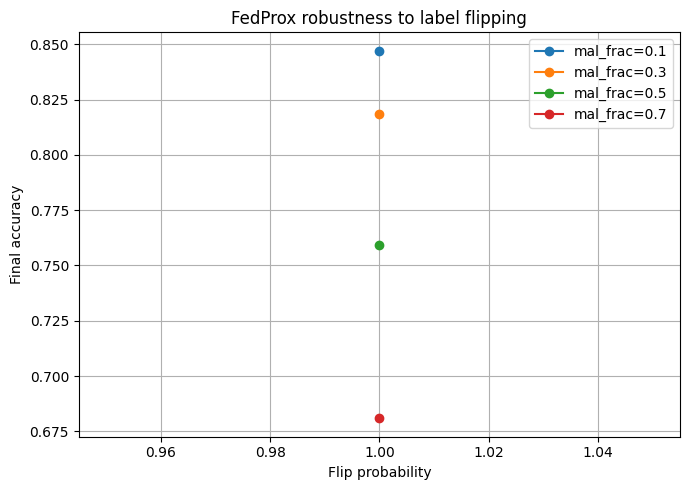

(raylet) [2026-09-16 15:06:42,134 E 196632 196632] (raylet) node_manager.cc:3064: 1 Workers (tasks / actors) killed due to memory pressure (OOM), 0 Workers crashed due to other reasons at node (ID: e1ca1e263f73bd5f12eabfd562582329756538bc7ec13f5e435bb64e, IP: 172.24.90.50) over the last time period. To see more information about the Workers killed on this node, use `ray logs raylet.out -ip 172.24.90.50`
(raylet) 
(raylet) Refer to the documentation on how to address the out of memory issue: https://docs.ray.io/en/latest/ray-core/scheduling/ray-oom-prevention.html. Consider provisioning more memory on this node or reducing task parallelism by requesting more CPUs per task. To adjust the kill threshold, set the environment variable `RAY_memory_usage_threshold` when starting Ray. To disable worker killing, set the environment variable `RAY_memory_monitor_refresh_ms` to zero.


In [ ]:
plt.figure(figsize=(7, 5))
for mf in mal_fracs:
    sub = df_results[df_results["mal_frac"] == mf].sort_values("flip_prob")
    plt.plot(sub["flip_prob"], sub["final_accuracy"], marker="o", label=f"mal_frac={mf}")
plt.xlabel("Flip probability")
plt.ylabel("Final accuracy")
plt.title("FedProx robustness to label flipping")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("fedprox_toniot_accuracy_vs_malfrac.png", dpi=300)
plt.show()